In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, explained_variance_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import os

from utils.models_utils import train_by_cluster

## Carga de datos

In [2]:
df_ventas_cluster = pd.read_csv('../data_preprocess/df_ventas_clusterizado.csv')

In [3]:
df_ventas_cluster['fecha'] = pd.to_datetime(df_ventas_cluster['fecha'])

In [4]:
df_ventas_cluster.describe()

,producto,udsVenta,fecha,year,month,day,udsVenta_reconstruida,dia_semana,bolOpen,bolHoliday,promociones,cluster
count,627800.000000,627800.000000,627800,627800.000000,627800.000000,627800.000000,627800.000000,627800.000000,627800.000000,627800.0,627800.000000,627800.000000
mean,500.759302,1.186645,2025-03-22 12:00:00,2024.721918,6.526027,15.720548,1.268659,3.006849,0.897260,0.1,0.131505,0.237209
min,1.000000,0.000000,2024-03-23 00:00:00,2024.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
25%,243.750000,0.000000,2024-09-21 00:00:00,2024.000000,4.000000,8.000000,0.000000,1.000000,1.000000,0.0,0.000000,0.000000
50%,505.000000,0.000000,2025-03-22 12:00:00,2025.000000,7.000000,16.000000,0.000000,3.000000,1.000000,0.0,0.000000,0.000000
75%,751.250000,2.000000,2025-09-21 00:00:00,2025.000000,10.000000,23.000000,2.000000,5.000000,1.000000,0.0,0.000000,0.000000
max,1000.000000,187.000000,2026-03-22 00:00:00,2026.000000,12.000000,31.000000,187.000000,6.000000,1.000000,1.0,1.000000,2.000000
std,292.455193,2.135917,NaN,0.650132,3.447854,8.796254,2.262564,2.001701,0.303619,0.3,0.337952,0.459537


In [5]:
df_ventas_cluster['month_sin'] = np.sin(2 * np.pi * df_ventas_cluster['month'] / 12)
df_ventas_cluster['month_cos'] = np.cos(2 * np.pi * df_ventas_cluster['month'] / 12)

## Split en test, val y test

In [6]:
df = df_ventas_cluster.copy()

# Definir cortes
train_end = "2025-07-31"
val_end = "2025-12-31"

df_train = df[df['fecha'] <= train_end]
df_val = df[(df['fecha'] > train_end) & (df['fecha'] <= val_end)]
df_test = df[df['fecha'] > val_end]

In [7]:
df_train.describe()

,producto,udsVenta,fecha,year,month,day,udsVenta_reconstruida,dia_semana,bolOpen,bolHoliday,promociones,cluster,month_sin,month_cos
count,426560.000000,426560.000000,426560,426560.000000,426560.000000,426560.000000,426560.000000,426560.000000,426560.000000,426560.000000,426560.000000,426560.000000,4.265600e+05,426560.000000
mean,500.759302,1.173127,2024-11-25 12:00:00.000000256,2024.427419,6.211694,15.933468,1.267672,2.997984,0.848790,0.147177,0.138888,0.237209,6.656585e-02,-0.200725
min,1.000000,0.000000,2024-03-23 00:00:00,2024.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000e+00,-1.000000
25%,243.750000,0.000000,2024-07-24 18:00:00,2024.000000,4.000000,8.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-5.000000e-01,-0.866025
50%,505.000000,0.000000,2024-11-25 12:00:00,2024.000000,6.000000,16.000000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,1.224647e-16,-0.500000
75%,751.250000,2.000000,2025-03-29 06:00:00,2025.000000,8.000000,24.000000,2.000000,5.000000,1.000000,0.000000,0.000000,0.000000,8.660254e-01,0.500000
max,1000.000000,187.000000,2025-07-31 00:00:00,2025.000000,12.000000,31.000000,187.000000,6.000000,1.000000,1.000000,1.000000,2.000000,1.000000e+00,1.000000
std,292.455303,2.102022,NaN,0.494705,3.071980,8.854434,2.219539,2.001513,0.358254,0.354283,0.345830,0.459537,6.758399e-01,0.706060


In [8]:
df_val.describe()

,producto,udsVenta,fecha,year,month,day,udsVenta_reconstruida,dia_semana,bolOpen,bolHoliday,promociones,cluster,month_sin,month_cos
count,131580.000000,131580.000000,131580,131580.0,131580.000000,131580.000000,131580.000000,131580.000000,131580.0,131580.0,131580.000000,131580.000000,1.315800e+05,1.315800e+05
mean,500.759302,1.229450,2025-10-15 23:59:59.999999744,2025.0,10.000000,15.803922,1.300213,3.000000,1.0,0.0,0.117905,0.237209,-6.450560e-01,3.724233e-01
min,1.000000,0.000000,2025-08-01 00:00:00,2025.0,8.000000,1.000000,0.000000,0.000000,1.0,0.0,0.000000,0.000000,-1.000000e+00,-5.000000e-01
25%,243.750000,0.000000,2025-09-08 00:00:00,2025.0,9.000000,8.000000,0.000000,1.000000,1.0,0.0,0.000000,0.000000,-8.660254e-01,-1.836970e-16
50%,505.000000,0.000000,2025-10-16 00:00:00,2025.0,10.000000,16.000000,0.000000,3.000000,1.0,0.0,0.000000,0.000000,-8.660254e-01,5.000000e-01
75%,751.250000,2.000000,2025-11-23 00:00:00,2025.0,11.000000,23.000000,2.000000,5.000000,1.0,0.0,0.000000,0.000000,-5.000000e-01,8.660254e-01
max,1000.000000,105.000000,2025-12-31 00:00:00,2025.0,12.000000,31.000000,105.000000,6.000000,1.0,0.0,1.000000,2.000000,-2.449294e-16,1.000000e+00
std,292.456071,2.226682,NaN,0.0,1.418833,8.835537,2.386762,2.006533,0.0,0.0,0.322497,0.459538,3.645865e-01,5.588235e-01


In [9]:
df_test.describe()

,producto,udsVenta,fecha,year,month,day,udsVenta_reconstruida,dia_semana,bolOpen,bolHoliday,promociones,cluster,month_sin,month_cos
count,69660.000000,69660.000000,69660,69660.0,69660.000000,69660.000000,69660.000000,69660.000000,69660.0,69660.0,69660.000000,69660.000000,69660.000000,6.966000e+04
mean,500.759302,1.188573,2026-02-09 23:59:59.999999744,2026.0,1.888889,14.259259,1.215102,3.074074,1.0,0.0,0.111987,0.237209,0.762330,5.042813e-01
min,1.000000,0.000000,2026-01-01 00:00:00,2026.0,1.000000,1.000000,0.000000,0.000000,1.0,0.0,0.000000,0.000000,0.500000,6.123234e-17
25%,243.750000,0.000000,2026-01-21 00:00:00,2026.0,1.000000,7.000000,0.000000,1.000000,1.0,0.0,0.000000,0.000000,0.500000,6.123234e-17
50%,505.000000,0.000000,2026-02-10 00:00:00,2026.0,2.000000,14.000000,0.000000,3.000000,1.0,0.0,0.000000,0.000000,0.866025,5.000000e-01
75%,751.250000,2.000000,2026-03-02 00:00:00,2026.0,3.000000,21.000000,2.000000,5.000000,1.0,0.0,0.000000,0.000000,1.000000,8.660254e-01
max,1000.000000,89.000000,2026-03-22 00:00:00,2026.0,3.000000,31.000000,89.000000,6.000000,1.0,0.0,1.000000,2.000000,1.000000,8.660254e-01
std,292.457059,2.165489,NaN,0.0,0.801239,8.206918,2.281390,1.992455,0.0,0.0,0.315352,0.459540,0.213066,3.451939e-01


In [10]:
total = len(df)
train_size = len(df_train)
val_size = len(df_val)
test_size = len(df_test)

print("Train:", train_size, f"({train_size/total:.2%})")
print("Val:", val_size, f"({val_size/total:.2%})")
print("Test:", test_size, f"({test_size/total:.2%})")

Train: 426560 (67.95%)
Val: 131580 (20.96%)
Test: 69660 (11.10%)


## Visualizacion

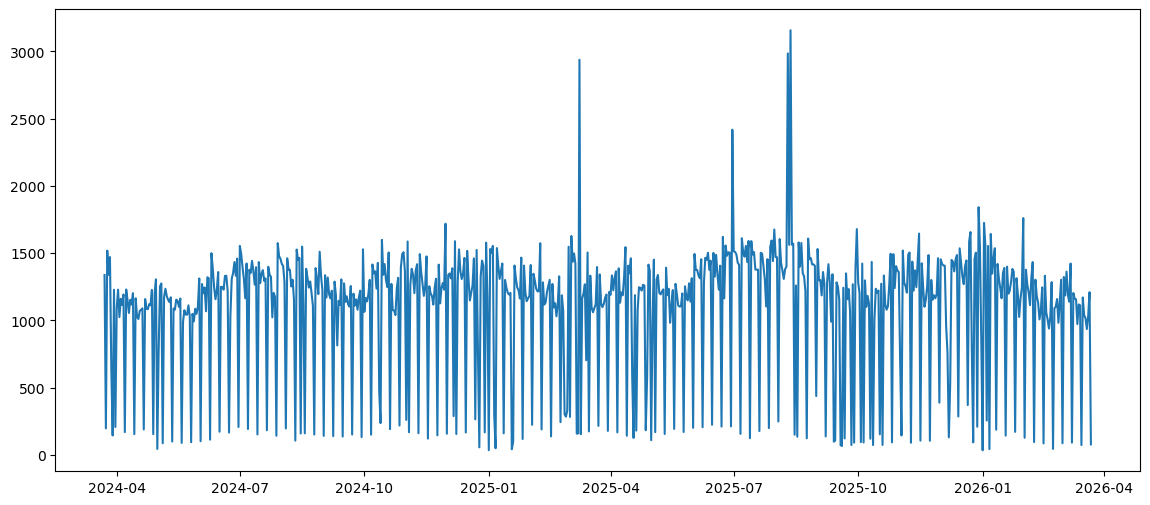

In [11]:
plt.figure(figsize=(14,6))

# Original
original_ts = df.groupby('fecha')['udsVenta_reconstruida'].sum()
plt.plot(original_ts.index, original_ts.values, label='Uds Venta reconstruida')


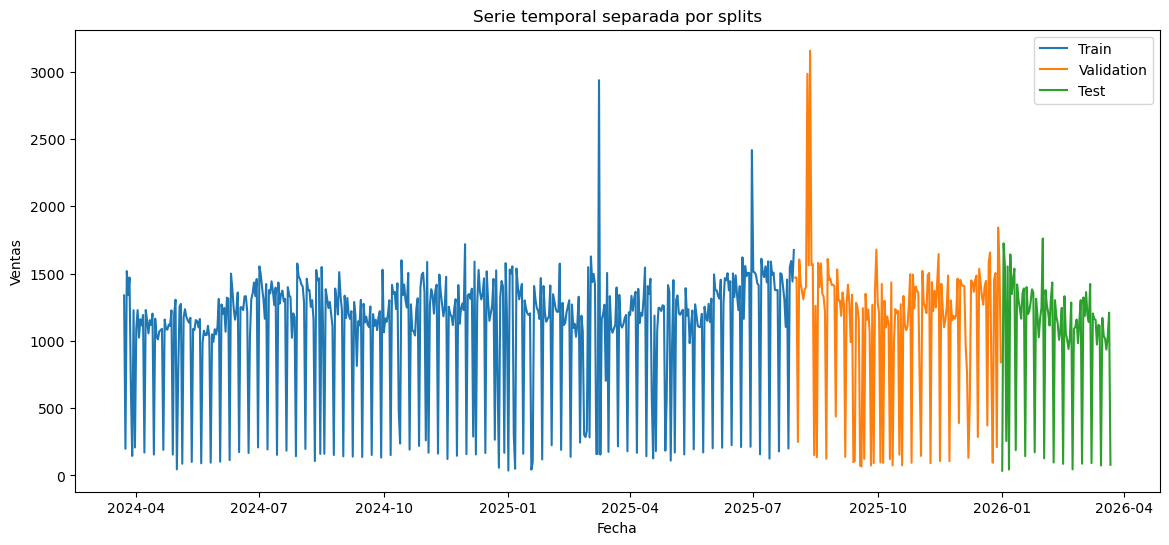

In [12]:
plt.figure(figsize=(14,6))

# Train
train_ts = df_train.groupby('fecha')['udsVenta_reconstruida'].sum()
plt.plot(train_ts.index, train_ts.values, label='Train')

# Val
val_ts = df_val.groupby('fecha')['udsVenta_reconstruida'].sum()
plt.plot(val_ts.index, val_ts.values, label='Validation')

# Test
test_ts = df_test.groupby('fecha')['udsVenta_reconstruida'].sum()
plt.plot(test_ts.index, test_ts.values, label='Test')

plt.title("Serie temporal separada por splits")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.savefig("imgs/uds_venta_totales_split_test_train_val_random_forest.png", dpi=300)

plt.show()

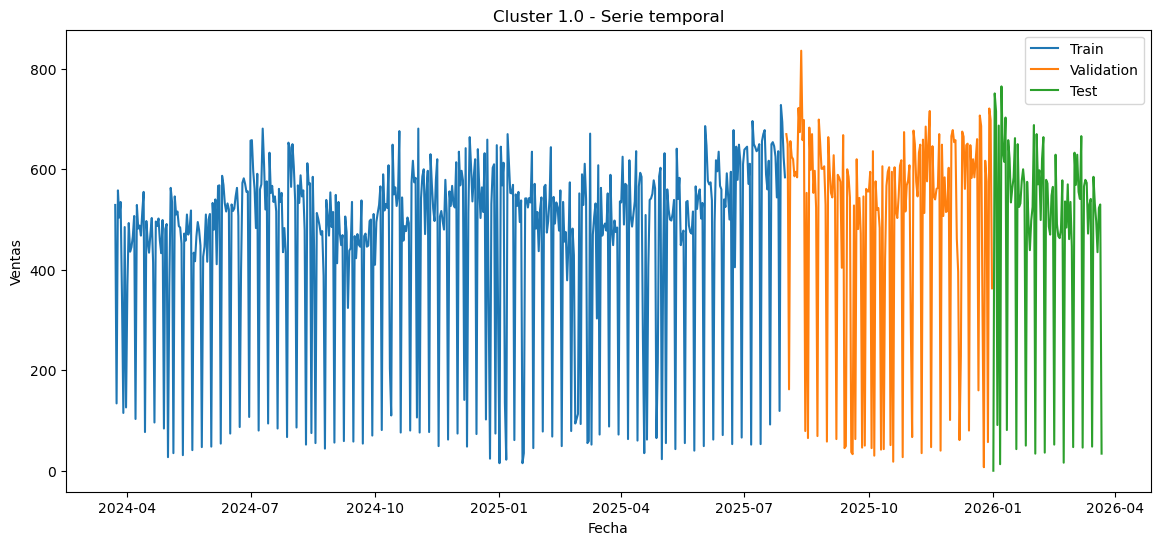

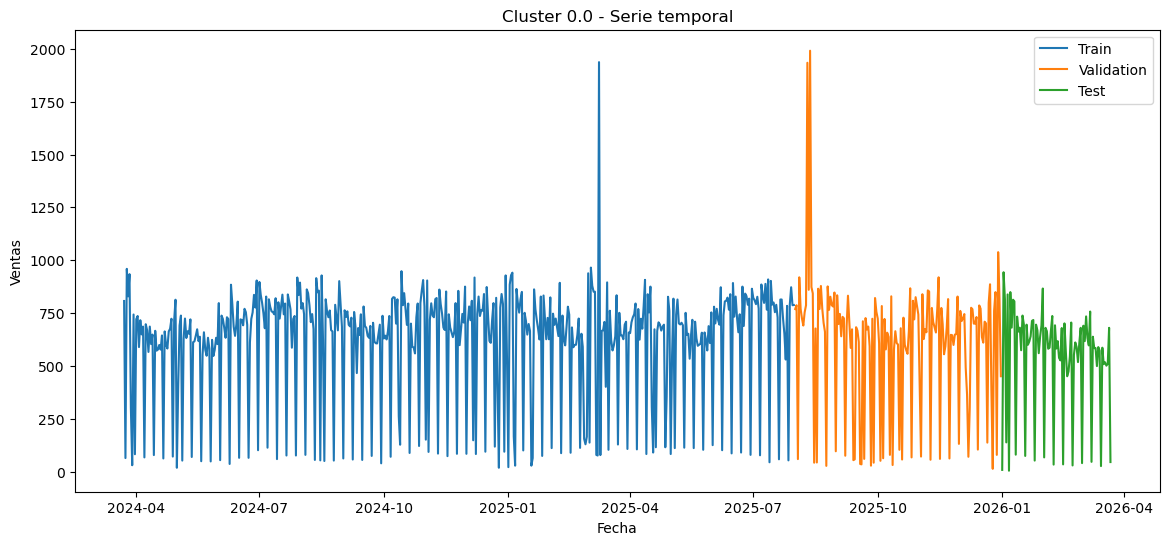

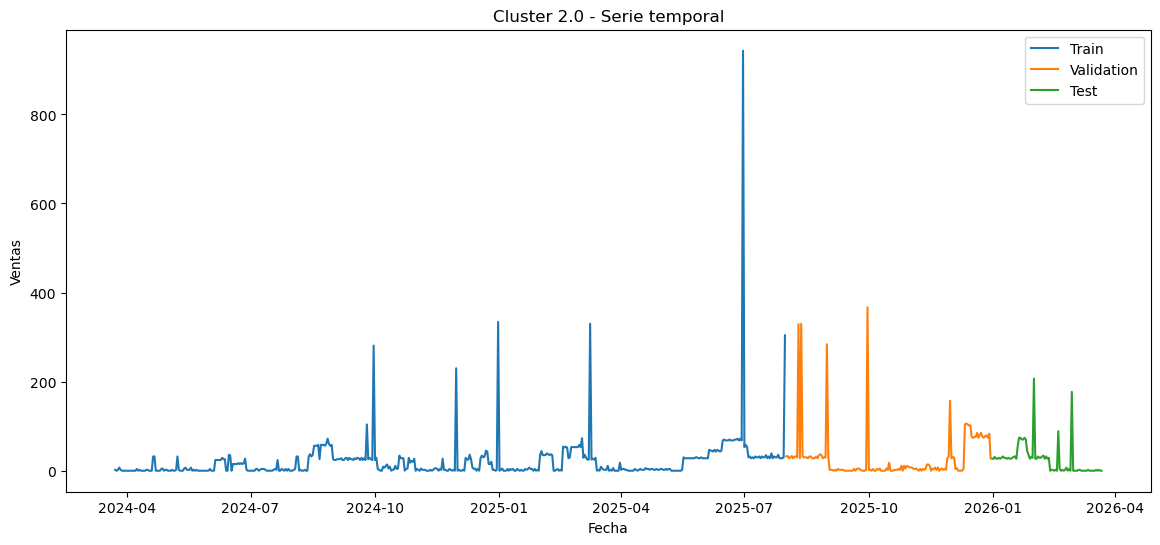

In [13]:
for c in df_train['cluster'].unique():
    
    plt.figure(figsize=(14,6))
    
    # Train
    train_ts = df_train[df_train['cluster']==c].groupby('fecha')['udsVenta_reconstruida'].sum()
    plt.plot(train_ts.index, train_ts.values, label='Train')
    
    # Val
    val_ts = df_val[df_val['cluster']==c].groupby('fecha')['udsVenta_reconstruida'].sum()
    plt.plot(val_ts.index, val_ts.values, label='Validation')
    
    # Test
    test_ts = df_test[df_test['cluster']==c].groupby('fecha')['udsVenta_reconstruida'].sum()
    plt.plot(test_ts.index, test_ts.values, label='Test')
    
    plt.title(f"Cluster {c} - Serie temporal")
    plt.xlabel("Fecha")
    plt.ylabel("Ventas")
    plt.legend()
    plt.savefig(f"imgs/uds_venta_totales_split_test_train_val_cluster_{c}_random_forest.png", dpi=300)

    
    plt.show()

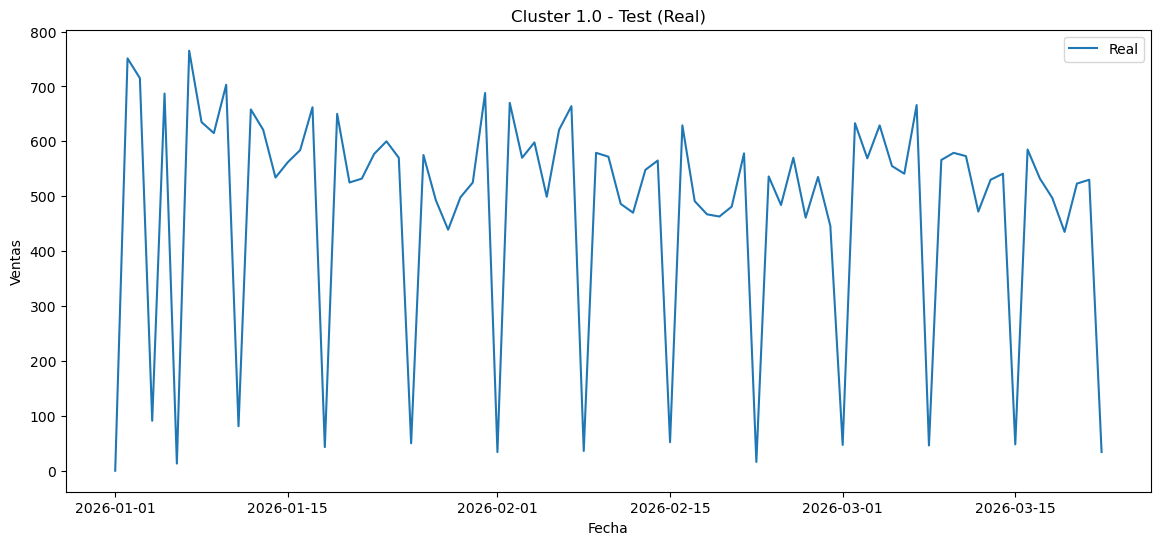

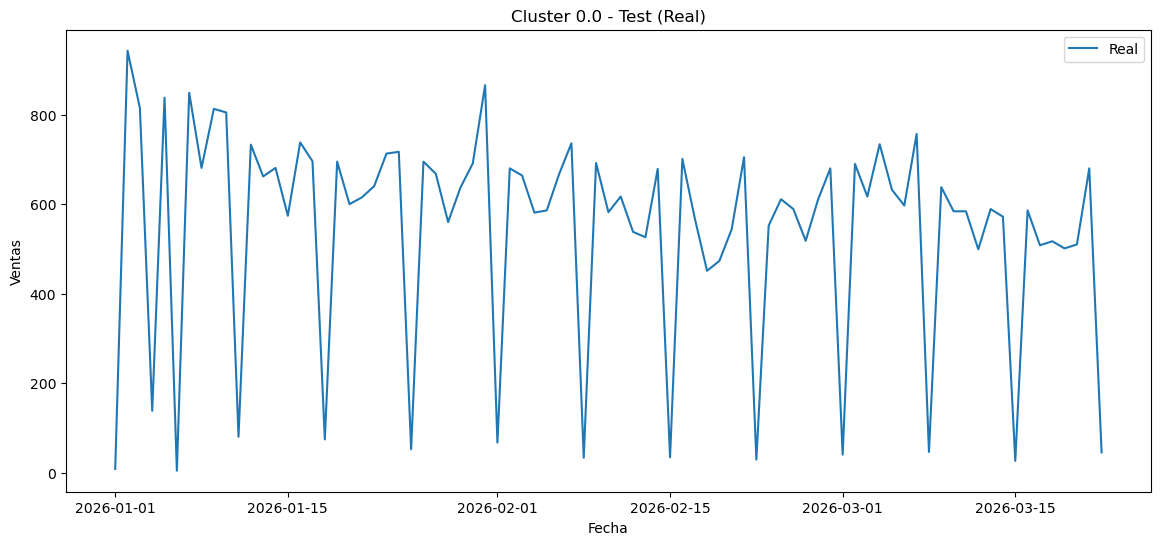

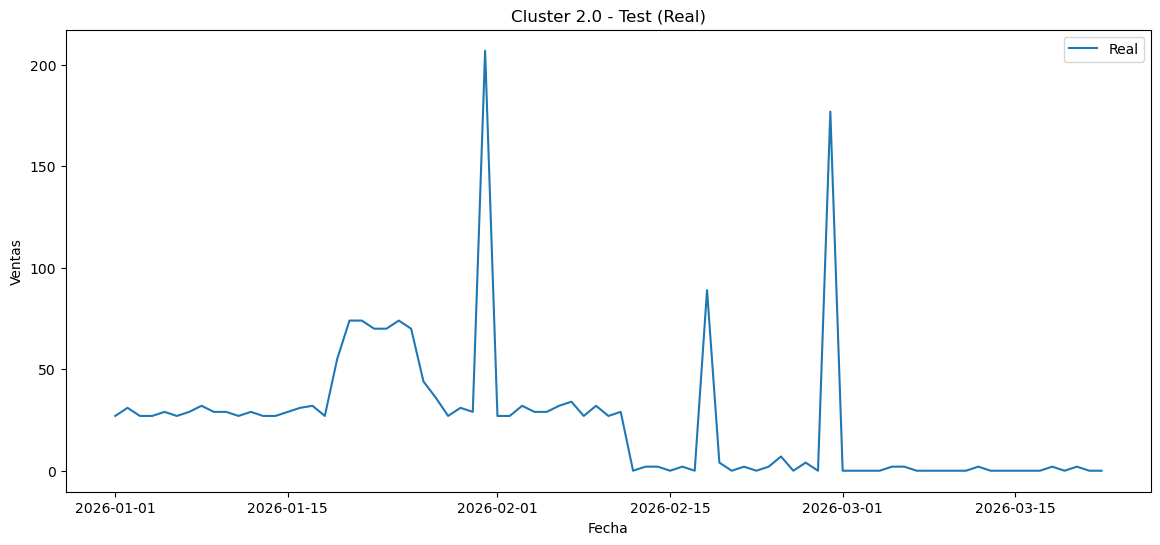

In [14]:
import matplotlib.pyplot as plt

for c in df_test['cluster'].unique():
    
    plt.figure(figsize=(14,6))
    
    ts = df_test[df_test['cluster']==c].groupby('fecha')['udsVenta_reconstruida'].sum()
    
    plt.plot(ts.index, ts.values, label='Real')
    
    plt.title(f"Cluster {c} - Test (Real)")
    plt.xlabel("Fecha")
    plt.ylabel("Ventas")
    plt.legend()
    
    plt.show()

## Random forest Baseline

In [15]:
def create_features(df):
    df = df.sort_values(['producto', 'fecha'])
    
    # Lags
    df['lag_1'] = df.groupby('producto')['udsVenta_reconstruida'].shift(1)
    df['lag_7'] = df.groupby('producto')['udsVenta_reconstruida'].shift(7)
    df['lag_14'] = df.groupby('producto')['udsVenta_reconstruida'].shift(14)
    df['lag_28'] = df.groupby('producto')['udsVenta_reconstruida'].shift(28)
    # Rolling
    df['rolling_mean_7'] = df.groupby('producto')['udsVenta_reconstruida'].shift(1).rolling(7).mean()
    
    return df

In [16]:
train = create_features(df_train)
val = create_features(df_val)
test = create_features(df_test)

In [17]:
# Eliminar nan por lags
train = train.dropna()
val = val.dropna()
test = test.dropna()

In [18]:
features = [ 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'dia_semana', 'month_sin','month_cos', 'bolOpen', 'bolHoliday', 'promociones' ]

In [19]:
results, models = train_by_cluster(
    train, val, test,
    features,
    model_fn=lambda: RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
)


🔹 Cluster 1.0
Val MAE: 1.9802 | RMSE: 2.7171 | ExpVar: 0.2740
Test MAE: 1.8524 | RMSE: 2.5869 | ExpVar: 0.2820

🔹 Cluster 0.0
Val MAE: 1.0787 | RMSE: 1.5249 | ExpVar: 0.1127
Test MAE: 1.0650 | RMSE: 1.4342 | ExpVar: 0.0746

🔹 Cluster 2.0
Val MAE: 2.2280 | RMSE: 5.9599 | ExpVar: 0.2796
Test MAE: 1.4068 | RMSE: 5.6819 | ExpVar: 0.2427


In [20]:
results_rf_df = pd.DataFrame(
    results,
    columns=[
        'cluster',
        'val_mae', 'val_rmse', 'val_exp_var',
        'test_mae', 'test_rmse', 'test_exp_var'
    ]
)
results_rf_df['model_name'] = "Random_forest"

In [21]:
results_rf_df

,cluster,val_mae,val_rmse,val_exp_var,test_mae,test_rmse,test_exp_var,model_name
0,1.0,1.980206,2.717113,0.273952,1.852400,2.586921,0.281993,Random_forest
1,0.0,1.078745,1.524915,0.112744,1.065019,1.434215,0.074642,Random_forest
2,2.0,2.227951,5.959917,0.279553,1.406847,5.681932,0.242731,Random_forest


In [45]:
def plot_predictions(
    df, model, features, cluster_id,
    split_name="test",
    model_name="model",
    save_dir="imgs"
):
    
    # Crear carpeta si no existe
    os.makedirs(save_dir, exist_ok=True)
    
    df_c = df[df['cluster'] == cluster_id].copy()
    
    # Predicción
    X = df_c[features]
    df_c['pred'] = model.predict(X)
    
    # Agregar por fecha
    ts_real = df_c.groupby('fecha')['udsVenta_reconstruida'].sum()
    ts_pred = df_c.groupby('fecha')['pred'].sum()
    
    # Plot
    plt.figure(figsize=(14,6))
    
    plt.plot(ts_real.index, ts_real.values, label='Real')
    plt.plot(ts_pred.index, ts_pred.values, label='Predicción')
    
    plt.title(f"{model_name} - Cluster {cluster_id} - {split_name}")
    plt.xlabel("Fecha")
    plt.ylabel("Ventas")
    plt.legend()
    
    # Nombre del archivo dinámico
    filename = f"{save_dir}/pred_{model_name}_cluster_{cluster_id}_{split_name}.png"
    
    plt.savefig(filename, dpi=300)
    plt.show()

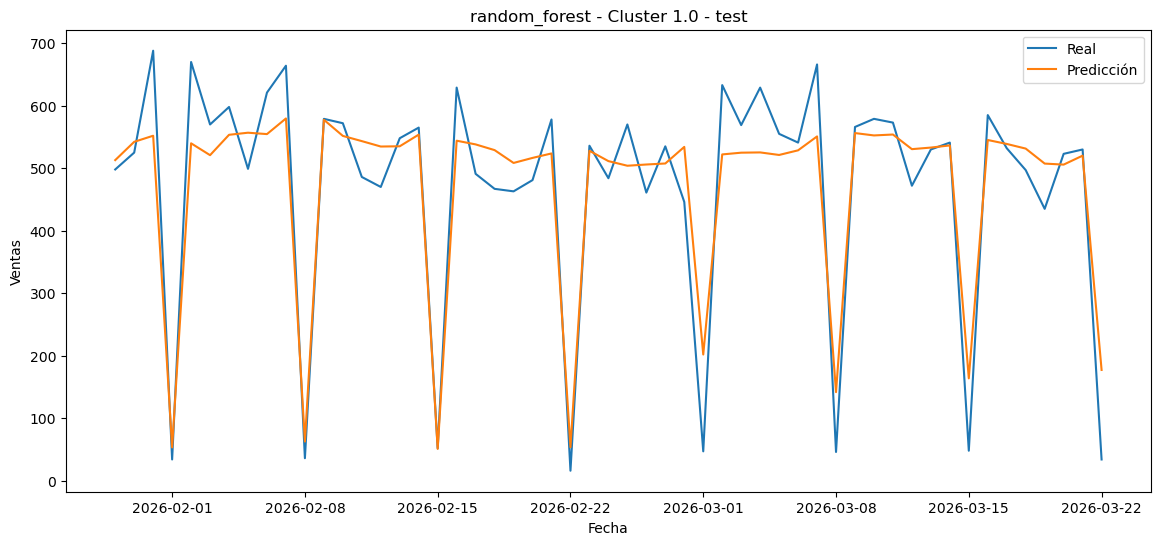

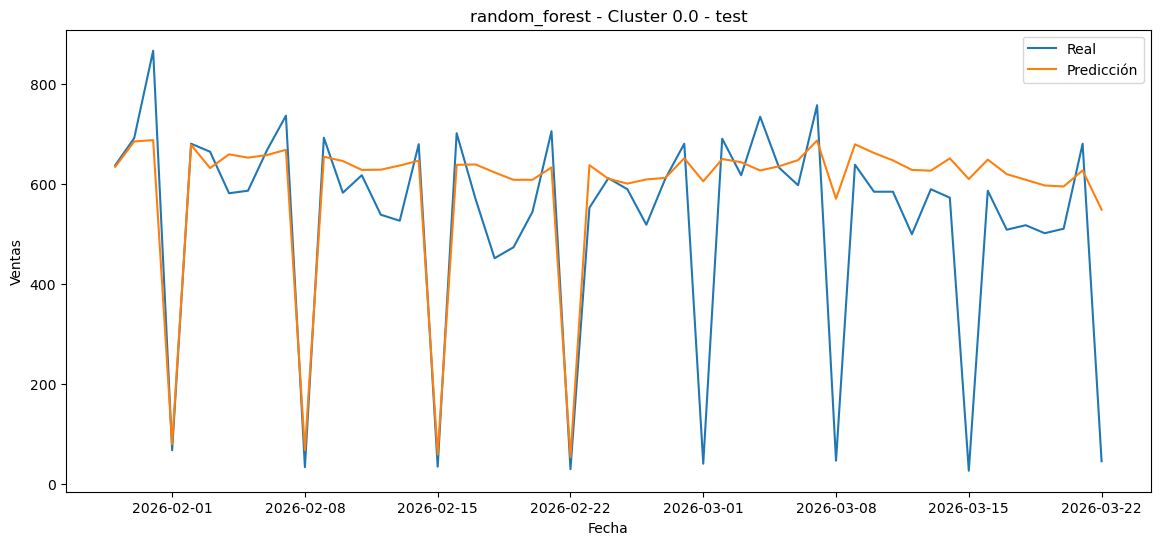

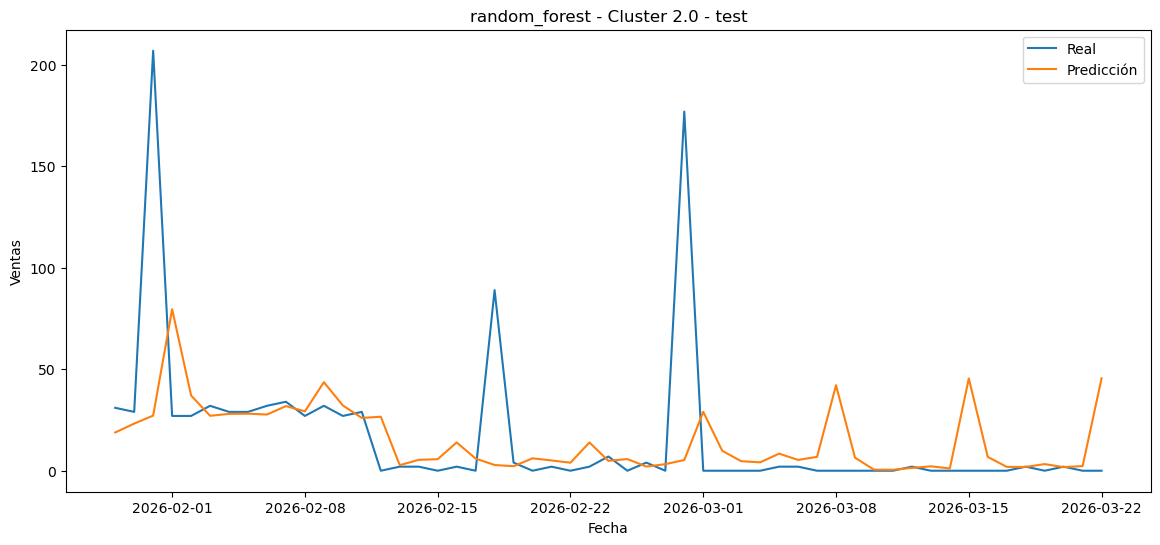

In [46]:
for c in models.keys():
    
    plot_predictions(
        df=test,
        model=models[c],
        features=features,
        cluster_id=c,
        split_name="test",
        model_name="random_forest"
    )

In [24]:
# Copias para no modificar originales
train_pred_df = train.copy()
val_pred_df = val.copy()
test_pred_df = test.copy()

# Inicializar columna
train_pred_df['pred_random_forest'] = np.nan
val_pred_df['pred_random_forest'] = np.nan
test_pred_df['pred_random_forest'] = np.nan

for c in models.keys():
    
    # TRAIN
    idx = train_pred_df['cluster'] == c
    train_pred_df.loc[idx, 'pred_random_forest'] = models[c].predict(train_pred_df.loc[idx, features])
    
    # VAL
    idx = val_pred_df['cluster'] == c
    val_pred_df.loc[idx, 'pred_random_forest'] = models[c].predict(val_pred_df.loc[idx, features])
    
    # TEST
    idx = test_pred_df['cluster'] == c
    test_pred_df.loc[idx, 'pred_random_forest'] = models[c].predict(test_pred_df.loc[idx, features])

In [25]:
for df_ in [train_pred_df, val_pred_df, test_pred_df]:
    df_['pred_random_forest_round'] = (
        np.round(df_['pred_random_forest'])  # redondeo
        .clip(0)                            # evitar negativos
        .astype(int)                        # entero
    )

In [26]:
df_with_pred = pd.concat([train_pred_df, val_pred_df, test_pred_df])

In [27]:
df_with_pred.head()

,producto,udsVenta,fecha,year,month,day,month_name,weekday_name,udsVenta_reconstruida,dia_semana,...,cluster,month_sin,month_cos,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,pred_random_forest,pred_random_forest_round
28,1,9,2024-04-20,2024,4,20,April,Saturday,9,5,...,1.0,0.866025,-0.5,5.0,12.0,5.0,2.0,5.142857,4.545132,5
29,1,0,2024-04-21,2024,4,21,April,Sunday,0,6,...,1.0,0.866025,-0.5,9.0,0.0,0.0,0.0,4.714286,0.185499,0
30,1,5,2024-04-22,2024,4,22,April,Monday,5,0,...,1.0,0.866025,-0.5,0.0,9.0,16.0,7.0,4.714286,5.175452,5
31,1,9,2024-04-23,2024,4,23,April,Tuesday,9,1,...,1.0,0.866025,-0.5,5.0,5.0,14.0,7.0,4.142857,5.383148,5
32,1,7,2024-04-24,2024,4,24,April,Wednesday,7,2,...,1.0,0.866025,-0.5,9.0,5.0,18.0,7.0,4.714286,5.582956,6


In [28]:
print("MAE continuo:", mean_absolute_error(test_pred_df['udsVenta_reconstruida'],
                                           test_pred_df['pred_random_forest']))

print("MAE redondeado:", mean_absolute_error(test_pred_df['udsVenta_reconstruida'],
                                            test_pred_df['pred_random_forest_round']))

MAE continuo: 1.2331554270245122
MAE redondeado: 1.230846862659061


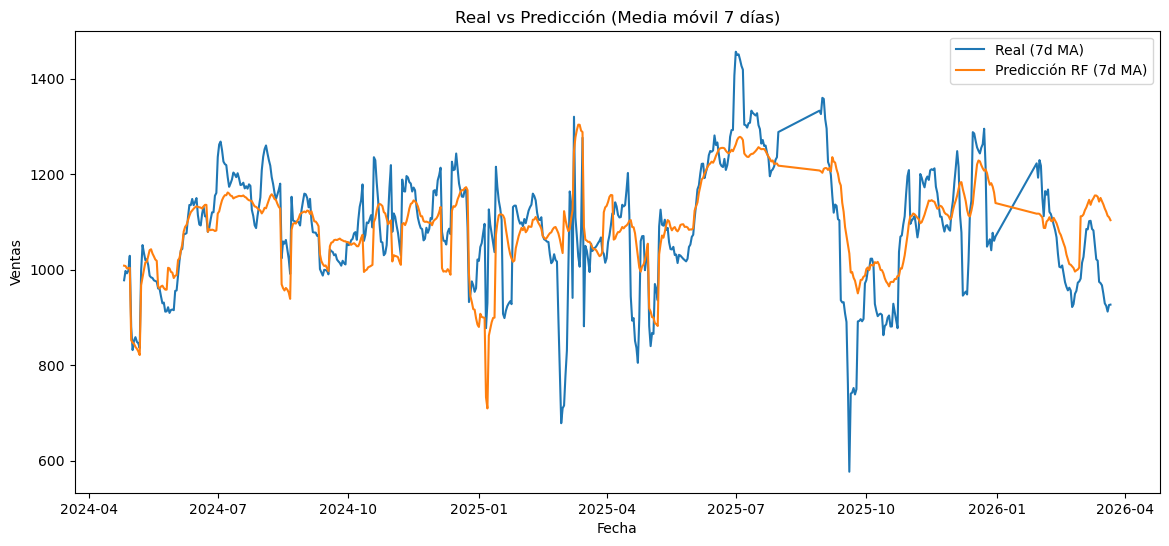

In [29]:
plt.figure(figsize=(14,6))

# Serie real
original_ts = df_with_pred.groupby('fecha')['udsVenta_reconstruida'].sum()

# Serie predicha (redondeada)
pred_ts = df_with_pred.groupby('fecha')['pred_random_forest_round'].sum()

# Aplicar rolling mean
original_smooth = original_ts.rolling(window=7).mean()
pred_smooth = pred_ts.rolling(window=7).mean()

# Plot
plt.plot(original_smooth.index, original_smooth.values, label='Real (7d MA)')
plt.plot(pred_smooth.index, pred_smooth.values, label='Predicción RF (7d MA)')

plt.title("Real vs Predicción (Media móvil 7 días)")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.savefig(f"imgs/valores_predichos_unidades_ventas_totales_random_forest.png", dpi=300)


plt.show()

## Random Forest Hyperparameter

In [31]:
import itertools
activate= False
if activate:
    features = [
        'lag_1', 'lag_7', 'lag_14', 'lag_28',
        'rolling_mean_7',
        'dia_semana', 'month_sin', 'month_cos',
        'bolOpen', 'bolHoliday', 'promociones'
    ]
    
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 15, None],
        'min_samples_leaf': [1, 5, 10]
    }
    
    param_combinations = list(itertools.product(
        param_grid['n_estimators'],
        param_grid['max_depth'],
        param_grid['min_samples_leaf']
    ))
    
    results = []
    models = {}
    best_params_by_cluster = {}
    
    for c in train['cluster'].unique():
        
        print(f"\n🔹 Cluster {c}")
        
        train_c = train[train['cluster'] == c]
        val_c = val[val['cluster'] == c]
        test_c = test[test['cluster'] == c]
        
        X_train = train_c[features]
        y_train = train_c['udsVenta_reconstruida']
        
        X_val = val_c[features]
        y_val = val_c['udsVenta_reconstruida']
        
        X_test = test_c[features]
        y_test = test_c['udsVenta_reconstruida']
        
        best_model = None
        best_params = None
        best_val_mae = np.inf
        
        search_rows = []
        
        for n_estimators, max_depth, min_samples_leaf in param_combinations:
            
            model = RandomForestRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                random_state=42,
                n_jobs=-1
            )
            
            model.fit(X_train, y_train)
            val_pred = model.predict(X_val)
            
            val_mae = mean_absolute_error(y_val, val_pred)
            val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
            val_exp_var = explained_variance_score(y_val, val_pred)
            
            search_rows.append({
                'cluster': c,
                'n_estimators': n_estimators,
                'max_depth': max_depth,
                'min_samples_leaf': min_samples_leaf,
                'val_mae': val_mae,
                'val_rmse': val_rmse,
                'val_exp_var': val_exp_var
            })
            
            if val_mae < best_val_mae:
                best_val_mae = val_mae
                best_model = model
                best_params = {
                    'n_estimators': n_estimators,
                    'max_depth': max_depth,
                    'min_samples_leaf': min_samples_leaf
                }
        
        models[c] = best_model
        best_params_by_cluster[c] = best_params
        
        test_pred = best_model.predict(X_test)
        val_pred = best_model.predict(X_val)
        
        val_mae = mean_absolute_error(y_val, val_pred)
        test_mae = mean_absolute_error(y_test, test_pred)
        
        val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
        
        val_exp_var = explained_variance_score(y_val, val_pred)
        test_exp_var = explained_variance_score(y_test, test_pred)
        
        print(f"Best params: {best_params}")
        print(f"Val MAE: {val_mae:.4f} | RMSE: {val_rmse:.4f} | ExpVar: {val_exp_var:.4f}")
        print(f"Test MAE: {test_mae:.4f} | RMSE: {test_rmse:.4f} | ExpVar: {test_exp_var:.4f}")
        
        results.append((
            c,
            best_params,
            val_mae, val_rmse, val_exp_var,
            test_mae, test_rmse, test_exp_var
        ))

## Decision tree Baseline

In [32]:
results_dt,dt_models = train_by_cluster(
    train, val, test,
    features,
    model_fn=lambda: DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    )
)


🔹 Cluster 1.0
Val MAE: 1.9998 | RMSE: 2.7622 | ExpVar: 0.2495
Test MAE: 1.8899 | RMSE: 2.6585 | ExpVar: 0.2418

🔹 Cluster 0.0
Val MAE: 1.0793 | RMSE: 1.5353 | ExpVar: 0.1004
Test MAE: 1.0704 | RMSE: 1.4428 | ExpVar: 0.0642

🔹 Cluster 2.0
Val MAE: 2.6366 | RMSE: 7.3288 | ExpVar: -0.0900
Test MAE: 1.2426 | RMSE: 5.9782 | ExpVar: 0.1637


In [33]:
train_pred_df['pred_decision_tree'] = np.nan
val_pred_df['pred_decision_tree'] = np.nan
test_pred_df['pred_decision_tree'] = np.nan

# Predicciones por clúster con Decision Tree
for c in dt_models.keys():
    
    # TRAIN
    idx = train_pred_df['cluster'] == c
    train_pred_df.loc[idx, 'pred_decision_tree'] = dt_models[c].predict(
        train_pred_df.loc[idx, features]
    )
    
    # VAL
    idx = val_pred_df['cluster'] == c
    val_pred_df.loc[idx, 'pred_decision_tree'] = dt_models[c].predict(
        val_pred_df.loc[idx, features]
    )
    
    # TEST
    idx = test_pred_df['cluster'] == c
    test_pred_df.loc[idx, 'pred_decision_tree'] = dt_models[c].predict(
        test_pred_df.loc[idx, features]
    )

# Redondeo de Decision Tree, conservando Random Forest
for df_ in [train_pred_df, val_pred_df, test_pred_df]:
    df_['pred_decision_tree_round'] = (
        np.round(df_['pred_decision_tree'])
        .clip(lower=0)
        .astype(int)
    )

# Concatenar todo si lo necesitas
df_with_pred = pd.concat([train_pred_df, val_pred_df, test_pred_df])

# Métricas en test para Decision Tree
mae_dt_cont = mean_absolute_error(
    test_pred_df['udsVenta_reconstruida'],
    test_pred_df['pred_decision_tree']
)

mae_dt_round = mean_absolute_error(
    test_pred_df['udsVenta_reconstruida'],
    test_pred_df['pred_decision_tree_round']
)

print(f"MAE continuo Decision Tree: {mae_dt_cont:.4f}")
print(f"MAE redondeado Decision Tree: {mae_dt_round:.4f}")

MAE continuo Decision Tree: 1.2426
MAE redondeado Decision Tree: 1.2465


In [34]:
df_with_pred.head()

,producto,udsVenta,fecha,year,month,day,month_name,weekday_name,udsVenta_reconstruida,dia_semana,...,month_cos,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,pred_random_forest,pred_random_forest_round,pred_decision_tree,pred_decision_tree_round
28,1,9,2024-04-20,2024,4,20,April,Saturday,9,5,...,-0.5,5.0,12.0,5.0,2.0,5.142857,4.545132,5,4.420361,4
29,1,0,2024-04-21,2024,4,21,April,Sunday,0,6,...,-0.5,9.0,0.0,0.0,0.0,4.714286,0.185499,0,0.169492,0
30,1,5,2024-04-22,2024,4,22,April,Monday,5,0,...,-0.5,0.0,9.0,16.0,7.0,4.714286,5.175452,5,4.715385,5
31,1,9,2024-04-23,2024,4,23,April,Tuesday,9,1,...,-0.5,5.0,5.0,14.0,7.0,4.142857,5.383148,5,8.100000,8
32,1,7,2024-04-24,2024,4,24,April,Wednesday,7,2,...,-0.5,9.0,5.0,18.0,7.0,4.714286,5.582956,6,4.715385,5


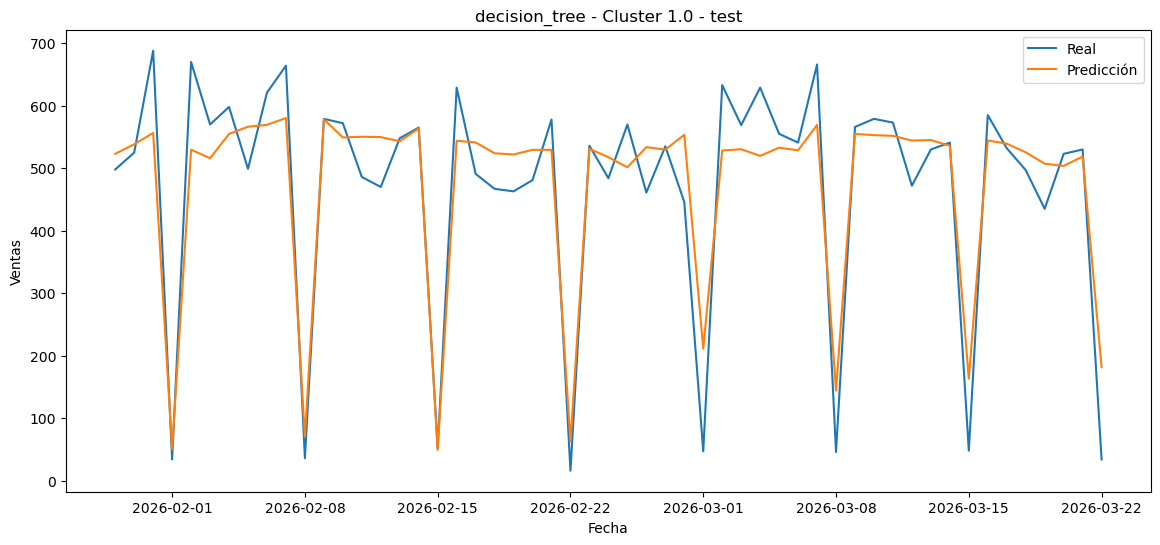

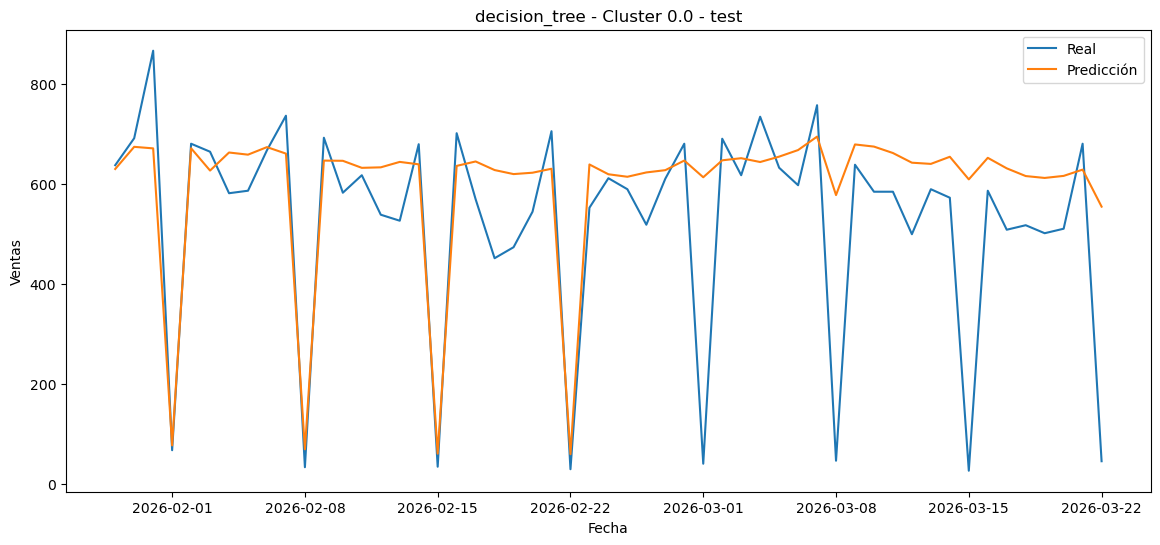

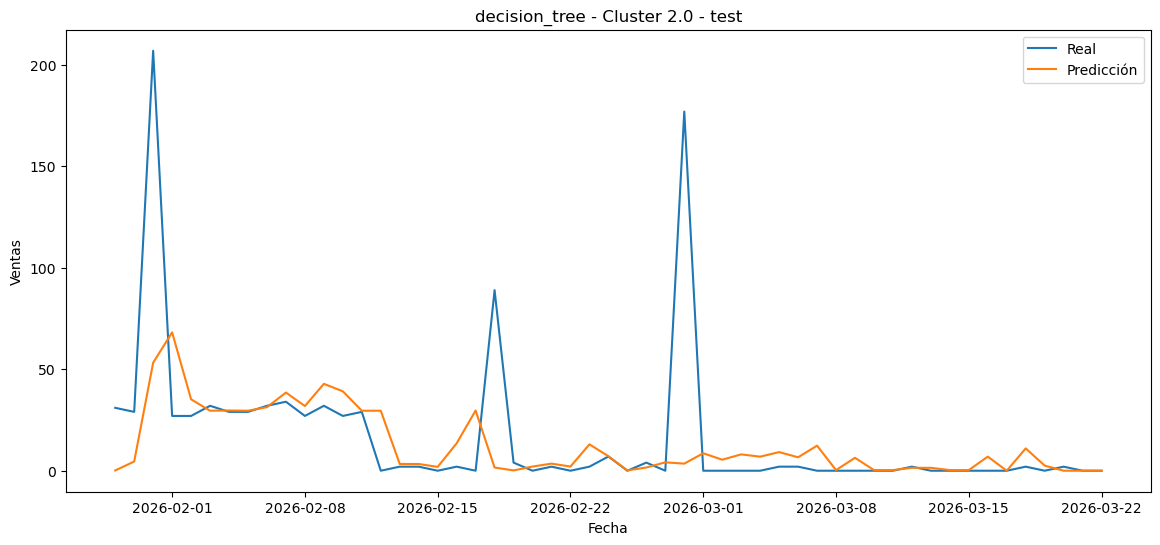

In [47]:
for c in dt_models.keys():
    plot_predictions(
        test,
        dt_models[c],
        features,
        c,
        split_name="test",
        model_name="decision_tree"
    )

In [36]:
results_dt_df = pd.DataFrame(
    results_dt,
    columns=[
        'cluster',
        'val_mae', 'val_rmse', 'val_exp_var',
        'test_mae', 'test_rmse', 'test_exp_var'
    ]
)
results_dt_df['model_name'] = "Decision_tree"

In [37]:
results_dt_df

,cluster,val_mae,val_rmse,val_exp_var,test_mae,test_rmse,test_exp_var,model_name
0,1.0,1.999803,2.762233,0.249515,1.889898,2.658528,0.241756,Decision_tree
1,0.0,1.079323,1.535348,0.100412,1.070410,1.442772,0.064219,Decision_tree
2,2.0,2.636588,7.328822,-0.089952,1.242630,5.978234,0.163701,Decision_tree


In [38]:
results_df = pd.concat([results_rf_df, results_dt_df], ignore_index=True)

print(results_df)

   cluster   val_mae  val_rmse  val_exp_var  test_mae  test_rmse  \
0      1.0  1.980206  2.717113     0.273952  1.852400   2.586921   
1      0.0  1.078745  1.524915     0.112744  1.065019   1.434215   
2      2.0  2.227951  5.959917     0.279553  1.406847   5.681932   
3      1.0  1.999803  2.762233     0.249515  1.889898   2.658528   
4      0.0  1.079323  1.535348     0.100412  1.070410   1.442772   
5      2.0  2.636588  7.328822    -0.089952  1.242630   5.978234   

   test_exp_var     model_name  
0      0.281993  Random_forest  
1      0.074642  Random_forest  
2      0.242731  Random_forest  
3      0.241756  Decision_tree  
4      0.064219  Decision_tree  
5      0.163701  Decision_tree  


## Decision tree Hyperparameters

In [48]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

activate = False

if activate:

    param_grid = {
        'max_depth': [5, 10, 20, None],
        'min_samples_leaf': [1, 5, 10],
        'min_samples_split': [2, 10, 20]
    }

    results_optimized = []
    best_models = {}

    for c in sorted(train['cluster'].unique()):

        print(f"\n🔹 Cluster {c}")

        train_c = train[train['cluster'] == c].copy()
        val_c = val[val['cluster'] == c].copy()
        test_c = test[test['cluster'] == c].copy()

        # 🔑 IMPORTANTE: ordenar por fecha
        train_c = train_c.sort_values(by='fecha')
        val_c = val_c.sort_values(by='fecha')
        test_c = test_c.sort_values(by='fecha')

        X_train = train_c[features]
        y_train = train_c['udsVenta_reconstruida']

        X_val = val_c[features]
        y_val = val_c['udsVenta_reconstruida']

        X_test = test_c[features]
        y_test = test_c['udsVenta_reconstruida']

        base_model = DecisionTreeRegressor(random_state=42)

        #TimeSeriesSplit en lugar de cv=3
        tscv = TimeSeriesSplit(n_splits=3)

        grid_search = GridSearchCV(
            estimator=base_model,
            param_grid=param_grid,
            cv=tscv,
            scoring='neg_mean_absolute_error',
            n_jobs=-1
        )

        grid_search.fit(X_train, y_train)

        best_model = grid_search.best_estimator_
        best_models[c] = best_model

        # Predicciones
        val_pred = best_model.predict(X_val)
        test_pred = best_model.predict(X_test)

        # Métricas VALIDACIÓN
        val_mae = mean_absolute_error(y_val, val_pred)
        val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
        val_exp_var = explained_variance_score(y_val, val_pred)

        # Métricas TEST
        test_mae = mean_absolute_error(y_test, test_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
        test_exp_var = explained_variance_score(y_test, test_pred)

        print(f"Best params: {grid_search.best_params_}")
        print(f"Val MAE: {val_mae:.4f} | RMSE: {val_rmse:.4f} | ExpVar: {val_exp_var:.4f}")
        print(f"Test MAE: {test_mae:.4f} | RMSE: {test_rmse:.4f} | ExpVar: {test_exp_var:.4f}")

        results_optimized.append({
            'cluster': c,
            'best_params': grid_search.best_params_,
            'val_mae': val_mae,
            'val_rmse': val_rmse,
            'val_exp_var': val_exp_var,
            'test_mae': test_mae,
            'test_rmse': test_rmse,
            'test_exp_var': test_exp_var,
            'model_name': 'Decision_tree'
        })

    # DataFrame final
    results_optimized_df = (
        pd.DataFrame(results_optimized)
        .sort_values(by='cluster')
        .reset_index(drop=True)
    )

    print("\nResultados optimizados:")
    print(results_optimized_df)


🔹 Cluster 0.0
Best params: {'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2}
Val MAE: 1.0781 | RMSE: 1.5281 | ExpVar: 0.1089
Test MAE: 1.0653 | RMSE: 1.4402 | ExpVar: 0.0664

🔹 Cluster 1.0
Best params: {'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Val MAE: 1.9953 | RMSE: 2.7430 | ExpVar: 0.2597
Test MAE: 1.8732 | RMSE: 2.5989 | ExpVar: 0.2754

🔹 Cluster 2.0
Best params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 20}
Val MAE: 1.9286 | RMSE: 5.8298 | ExpVar: 0.3123
Test MAE: 1.4785 | RMSE: 5.6451 | ExpVar: 0.2522

Resultados optimizados:
   cluster                                        best_params   val_mae  \
0      0.0  {'max_depth': 10, 'min_samples_leaf': 10, 'min...  1.078110   
1      1.0  {'max_depth': 5, 'min_samples_leaf': 10, 'min_...  1.995257   
2      2.0  {'max_depth': 5, 'min_samples_leaf': 1, 'min_s...  1.928636   

   val_rmse  val_exp_var  test_mae  test_rmse  test_exp_var     model_name  
0  1.528109     0.108864  

In [49]:
pd.set_option('display.max_colwidth', None)

results_optimized_df

,cluster,best_params,val_mae,val_rmse,val_exp_var,test_mae,test_rmse,test_exp_var,model_name
0,0.0,"{'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2}",1.078110,1.528109,0.108864,1.065252,1.440223,0.066432,Decision_tree
1,1.0,"{'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}",1.995257,2.743037,0.259744,1.873238,2.598912,0.275400,Decision_tree
2,2.0,"{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 20}",1.928636,5.829778,0.312341,1.478462,5.645131,0.252201,Decision_tree


## XGBOOST Baseline

## LGB Baseline